In [232]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
#!pip install pmdarima
from pmdarima import auto_arima
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pmd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
import scipy.stats as stats
from scipy.special import inv_boxcox
from sklearn.metrics import r2_score
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error
 


Master_File= '/Users/kellyxu/Documents/Uni/Capstone/nsw_clean_outputs/Final_master_daily_with_env.csv'

demanddaily= pd.read_csv(Master_File)

demanddaily = demanddaily.set_index('DATE')
df = demanddaily[['demand_mw_mean','rn_temp_c', 'precipitation', 'irradiance', 'wind_speed', 'humidity','is_weekend','is_holiday','cloud_cover']]
df = df.rename(columns = {'demand_mw_mean' : 'demand','rn_temp_c':'temp'})
df


,demand,temp,precipitation,irradiance,wind_speed,humidity,is_weekend,is_holiday,cloud_cover
DATE,,,,,,,,,
2010-01-01,7801.352917,24.172708,3.182,6566.473,1.937417,0.013958,0,1,0.658750
2010-01-02,8017.459792,22.872292,9.976,7220.681,2.290292,0.013083,1,0,0.308708
2010-01-03,7399.899583,19.881917,2.934,6975.007,2.590208,0.010917,1,0,0.415042
2010-01-04,8241.720208,21.534125,0.264,8053.354,2.396375,0.011042,0,0,0.128042
2010-01-05,8827.813125,23.808500,3.389,8012.107,1.899917,0.012917,0,0,0.331542
...,...,...,...,...,...,...,...,...,...
2021-03-14,7092.584375,16.482250,18.285,3158.443,3.322542,0.009583,1,0,0.580917
2021-03-15,6930.622708,18.190708,0.553,6280.335,2.210917,0.008875,0,0,0.127167
2021-03-16,7330.375208,19.493000,4.470,5050.232,2.814458,0.010833,0,0,0.658208


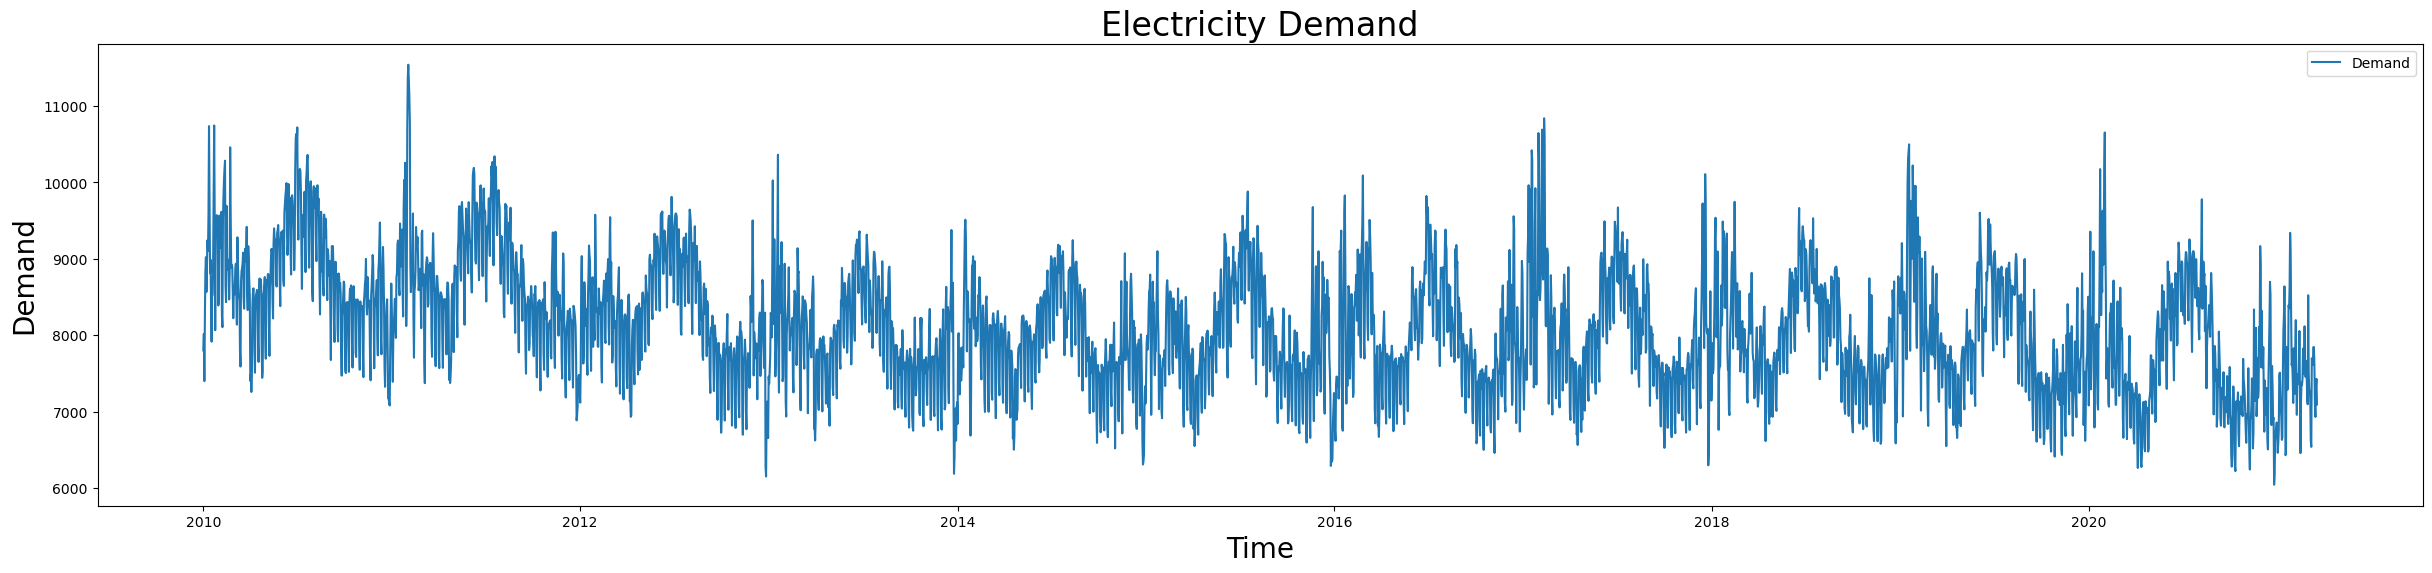

In [123]:
df.index = pd.to_datetime(df.index)
plt.figure(figsize= (30,6))
plt.plot(df.index, df['demand'], label='Demand')
plt.title('Electricity Demand', fontsize=24)
plt.xlabel('Time', fontsize = 20)
plt.ylabel('Demand', fontsize = 20)
plt.legend()
plt.show()

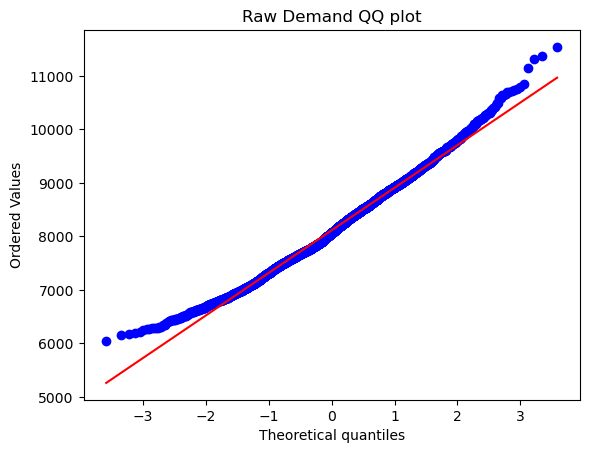

In [217]:
stats.probplot(df['demand'].dropna(), plot=plt)
plt.title('Raw Demand QQ plot')
plt.show()

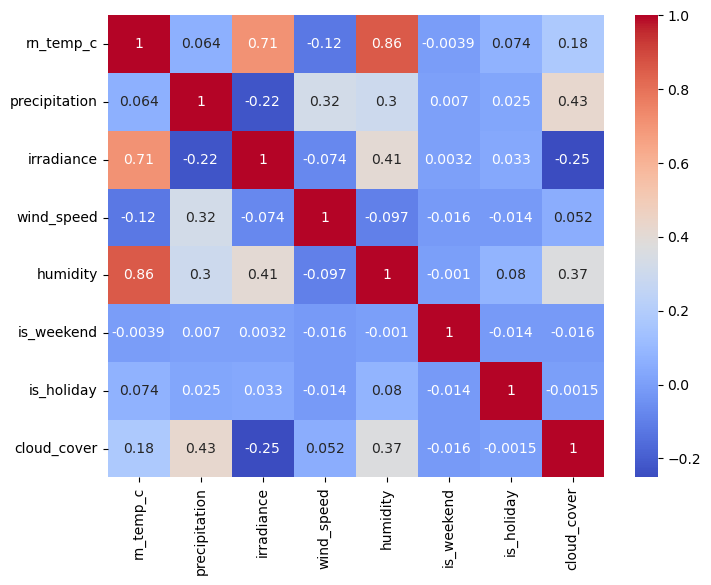

In [216]:
exog = demanddaily[['rn_temp_c', 'precipitation', 'irradiance', 'wind_speed', 'humidity','is_weekend','is_holiday','cloud_cover']]
corr_matrix = exog.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

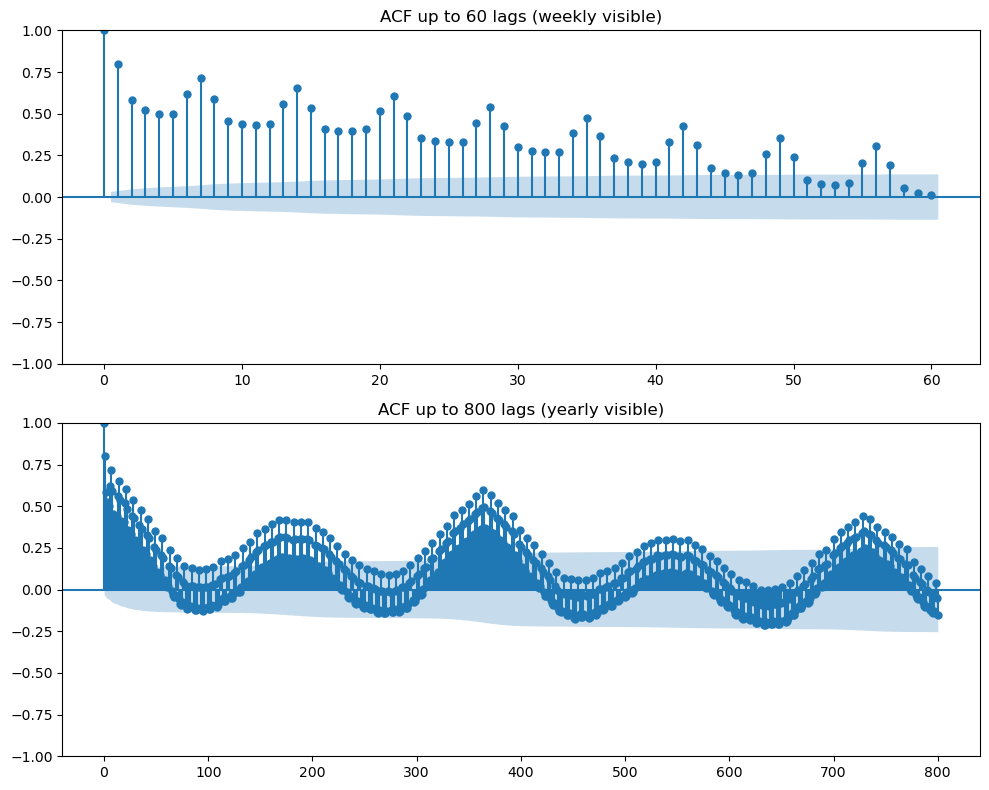

In [220]:
fig, axes = plt.subplots(2, 1, figsize=(10,8))
 
# Look for weekly pattern
plot_acf(df['demand'], lags=60, ax=axes[0])
axes[0].set_title("ACF up to 60 lags (weekly visible)")
 
# Look for yearly pattern
plot_acf(df['demand'], lags=800, ax=axes[1])
axes[1].set_title("ACF up to 800 lags (yearly visible)")
 
plt.tight_layout()
plt.show()

In [169]:
model=pmd.auto_arima(df['demand'],start_p=1,start_q=1,m=7,seasonal=True,trace=True,information_criterion='aic')

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=2.89 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=62602.077, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=61150.338, Time=0.91 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=61755.390, Time=1.08 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=62600.077, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=62599.080, Time=0.11 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=60694.773, Time=2.20 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=3.50 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=3.92 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=60693.303, Time=1.59 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=61148.352, Time=0.59 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=4.73 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=1.87 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=60694.270, Time=2.12 sec
 ARIMA(1,1,1)(2,0,0)[7] intercept   : AIC=inf, Ti

In [230]:

## Split train / validation / test
 
# split sizes

y = df['demand'].astype('float64')

X= df[['temp', 'precipitation', 'wind_speed','irradiance','is_weekend','is_holiday','cloud_cover']]


train_end = 8*365        # ~8 years of daily data
val_end   = train_end + 2*365
test_end  = val_end + 365
 
train  = y.iloc[:train_end] #y train
val   = y.iloc[train_end:val_end] #y validation
test  = y.iloc[val_end:test_end] #y test
 
exog_train = X[:train_end]
exog_val   = X[train_end:val_end]
exog_test = X[val_end:test_end]
 

print('Test set length:', len(test))
print('Train set length:',len(train))
print('Val set length:',len(val))

Test set length: 365
Train set length: 2920
Val set length: 730


In [236]:
## Evaluate ARIMA model over validation data
# Rolling 28days over the validation period
step = 28
maes = [] #MAEs

max_N = len(y)

start = train_end
while start + step <= val_end:
    y_tr = y.iloc[:start].to_numpy()
    X_tr = exog_train[:start]
    X_fut = exog_train[start:start+step]
    y_true = y.iloc[start:start+step].to_numpy()
   
    mdl = pmd.auto_arima(y_tr
                     , exogenous = X_tr
                     , start_p=1, start_q=1
                     , test='kpss', m=7
                     , seasonal=True
                     , trace=True
                     , with_intercept = False
    )
 
    y_hat = mdl.predict(n_periods=step, X=X_fut)
    maes.append(mean_absolute_error(y_true, y_hat))
    start += step
 
print(f"Validation 28d MAE: mean={np.mean(maes):.2f}, std={np.std(maes):.2f}, n_windows={len(maes)}")
 

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=13.30 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=44663.386, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=43355.520, Time=0.33 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=43910.380, Time=0.41 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=44657.747, Time=0.04 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=43025.334, Time=0.61 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=2.49 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=1.63 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=43023.380, Time=0.28 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=43353.858, Time=0.10 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=1.82 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=0.96 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=43025.298, Time=0.76 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=1.89 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=43025.373, T

 ARIMA(0,1,0)(2,0,0)[7]             : AIC=45961.143, Time=0.20 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=46334.876, Time=0.10 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=2.13 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=0.76 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=45962.822, Time=0.67 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=2.44 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=45963.139, Time=1.65 sec

Best model:  ARIMA(0,1,0)(2,0,0)[7]          
Total fit time: 15.248 seconds
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=1.76 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=48055.723, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=46744.934, Time=0.32 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=47303.807, Time=0.41 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=48050.525, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=46368.459, Time=0.70 sec
 ARIMA(1,1,0)(2,0,1)[7]         

 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=2.41 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=51095.897, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=49774.673, Time=0.36 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=50332.081, Time=0.43 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=51090.135, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=49367.839, Time=0.72 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=2.63 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=1.16 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=49365.892, Time=0.22 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=49773.521, Time=0.10 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=2.04 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=0.99 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=49367.791, Time=0.68 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=2.37 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=49367.881, Time=1.76 sec

Best model:  ARIMA(0,1,0)(2,0,

 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=2.36 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=1.05 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=52205.518, Time=0.84 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=2.45 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=52205.556, Time=1.99 sec

Best model:  ARIMA(0,1,0)(2,0,0)[7]          
Total fit time: 18.196 seconds
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=2.71 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=54467.095, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=53040.186, Time=0.39 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=53642.283, Time=0.45 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=54460.437, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=52610.486, Time=0.78 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=3.29 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=1.21 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=52

In [238]:
mdl = SARIMAX(train,
              exog=X_tr,
              order=(0, 1, 0),
              seasonal_order=(2, 0, 0, 7)).fit()
 
print(mdl.summary())

/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           10     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.08664D+00    |proj g|=  3.23178D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   10      4      6      1     0     0   5.460D-05   7.087D+00
  F =   7.0866373308695536     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
                                     SARIMAX Results                                     
Dep. Variable:                            demand   No. Observations:                 2920
Model:        